In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
orders_df=pd.read_csv("/content/orders DA.csv")
customers_df=pd.read_csv("/content/customers DA.csv")
inventory_df=pd.read_csv("/content/inventory DA.csv")
order_items_df=pd.read_csv("/content/order_items DA.csv")
payments_df=pd.read_csv("/content/payments DA.csv")
products_df=pd.read_csv("/content/products DA.csv")
returns_df=pd.read_csv("/content/returns DA.csv")
suppliers_df=pd.read_csv("/content/suppliers DA.csv")
print("All * datasets are loaded successfully")

All * datasets are loaded successfully


In [3]:
print("Orders:", orders_df.shape)
print("Customers:", customers_df.shape)
print("Order Items:", order_items_df.shape)
print("Products:", products_df.shape)
print("Payments:", payments_df.shape)
print("Returns:", returns_df.shape)
print("Inventory:", inventory_df.shape)
print("Suppliers:", suppliers_df.shape)

Orders: (50000, 19)
Customers: (10000, 17)
Order Items: (100000, 11)
Products: (1000, 17)
Payments: (50000, 13)
Returns: (10000, 10)
Inventory: (1000, 11)
Suppliers: (200, 14)


In [4]:
print("Orders Columns:")
print(orders_df.columns.tolist())

print("\nCustomers Columns:")
print(customers_df.columns.tolist())

print("\nOrder Items Columns:")
print(order_items_df.columns.tolist())

print("\nProducts Columns:")
print(products_df.columns.tolist())

print("\nPayments Columns:")
print(payments_df.columns.tolist())

print("\nReturns Columns:")
print(returns_df.columns.tolist())

print("\nInventory Columns:")
print(inventory_df.columns.tolist())

print("\nSuppliers Columns:")
print(suppliers_df.columns.tolist())

Orders Columns:
['order_id', 'customer_id', 'order_date', 'order_time', 'status', 'city', 'state', 'pincode', 'total_amount', 'gst_amount', 'shipping_charge', 'discount_amount', 'final_amount', 'payment_method', 'shipping_partner', 'tracking_id', 'delivered_date', 'is_cod', 'channel']

Customers Columns:
['customer_id', 'first_name', 'last_name', 'email', 'phone', 'city', 'state', 'pincode', 'gender', 'age', 'segment', 'registration_date', 'last_login_date', 'is_verified', 'is_active', 'total_orders', 'total_spent']

Order Items Columns:
['item_id', 'order_id', 'product_id', 'product_name', 'category', 'quantity', 'unit_price', 'gst_rate', 'gst_amount', 'discount_amount', 'total_price']

Products Columns:
['product_id', 'product_name', 'category', 'subcategory', 'brand', 'sku', 'mrp', 'selling_price', 'cost_price', 'gst_rate', 'hsn_code', 'weight_grams', 'supplier_id', 'rating', 'review_count', 'is_active', 'launch_date']

Payments Columns:
['payment_id', 'order_id', 'customer_id', 'pa

In [5]:
orders_df["order_date"] = pd.to_datetime(
    orders_df["order_date"],
    errors="coerce"
)

/tmp/ipykernel_2004/1516884567.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  orders_df["order_date"] = pd.to_datetime(


In [6]:
orders_df[["order_date"]].head()

,order_date
0,2025-05-22
1,2023-10-16
2,2023-10-08
3,2023-10-02
4,2024-06-15


**1. Gross Merchandise Value (GMV)**


In [7]:
gmv = orders_df["final_amount"].sum()

print("Gross Merchandise Value (GMV): ₹", round(gmv, 2))



Gross Merchandise Value (GMV): ₹ 3147385544.58


**2. Net Revenue**

In [8]:
delivered_orders = orders_df[
    orders_df["status"] == "Delivered"
]

net_revenue = delivered_orders["final_amount"].sum()

print("Net Revenue: ₹", round(net_revenue, 2))

Net Revenue: ₹ 2053858611.96


**3.Average Order Value**


In [9]:
delivered_order_count = len(delivered_orders)

aov = net_revenue / delivered_order_count

print("Average Order Value (AOV): ₹", round(aov, 2))

Average Order Value (AOV): ₹ 63197.59


**4.Cancellation Rate**

In [10]:
total_orders = len(orders_df)

cancelled_orders = len(
    orders_df[orders_df["status"] == "Cancelled"]
)

cancellation_rate = (
    cancelled_orders / total_orders
) * 100

print("Total Orders:", total_orders)
print("Cancelled Orders:", cancelled_orders)
print("Cancellation Rate:", round(cancellation_rate, 2), "%")

Total Orders: 50000
Cancelled Orders: 5996
Cancellation Rate: 11.99 %


In [11]:
if cancellation_rate < 10:
    print("Target: < 10%")
    print("Status: Target Met")
else:
    print("Target: < 10%")
    print("Status: Target Missed")

Target: < 10%
Status: Target Missed


**5.Returns Rate**

In [12]:
return_records = returns_df["order_id"].nunique()

return_rate = (
    return_records / delivered_order_count
) * 100

print("Return Records:", return_records)
print("Delivered Orders:", delivered_order_count)
print("Return Rate:", round(return_rate, 2), "%")

Return Records: 10000
Delivered Orders: 32499
Return Rate: 30.77 %


In [13]:
if return_rate < 8:
    print("Target: < 8%")
    print("Status: Target Met")
else:
    print("Target: < 8%")
    print("Status: Target Missed")

Target: < 8%
Status: Target Missed


**6. Customer Lifetime Value**

In [14]:
clv = (
    customers_df
    .groupby("segment")["total_spent"]
    .mean()
    .round(2)
    .reset_index()
)

clv.columns = [
    "Segment",
    "Average_Customer_Value"
]

clv

,Segment,Average_Customer_Value
0,Budget,186178.81
1,Inactive,32249.08
2,New,274866.48
3,Premium,532735.00
4,Regular,361870.72


In [15]:
clv = (
    customers_df
    .groupby("segment")["total_spent"]
    .mean()
    .round(2)
    .reset_index()
)

clv.columns = [
    "Segment",
    "Average_Customer_Value"
]

clv

,Segment,Average_Customer_Value
0,Budget,186178.81
1,Inactive,32249.08
2,New,274866.48
3,Premium,532735.00
4,Regular,361870.72


In [16]:
premium_value = customers_df.loc[
    customers_df["segment"] == "Premium",
    "total_spent"
].mean()

regular_value = customers_df.loc[
    customers_df["segment"] == "Regular",
    "total_spent"
].mean()

premium_regular_ratio = (
    premium_value / regular_value
)

print(
    "Premium / Regular Ratio:",
    round(premium_regular_ratio, 2),
    "x"
)

Premium / Regular Ratio: 1.47 x


In [17]:
if premium_regular_ratio >= 3:
    print("Target: Premium should be 3x Regular")
    print("Status: Target Met")
else:
    print("Target: Premium should be 3x Regular")
    print("Status: Target Missed")

Target: Premium should be 3x Regular
Status: Target Missed


**7. Month-over-Month Growth**

In [18]:
orders_df["month"] = orders_df["order_date"].dt.to_period("M")

In [19]:
monthly_gmv = (
    orders_df
    .groupby("month")["final_amount"]
    .sum()
    .reset_index()
)

monthly_gmv.columns = [
    "Month",
    "GMV"
]

monthly_gmv

,Month,GMV
0,2023-06,2.738485e+07
1,2023-07,1.289205e+08
2,2023-08,1.281220e+08
3,2023-09,1.374625e+08
4,2023-10,1.324709e+08
5,2023-11,1.372634e+08
6,2023-12,1.369234e+08
7,2024-01,1.314500e+08
8,2024-02,1.209459e+08
9,2024-03,1.336701e+08


In [20]:
monthly_gmv["MoM_Growth_%"] = (
    monthly_gmv["GMV"]
    .pct_change()
    * 100
)

monthly_gmv["MoM_Growth_%"] = (
    monthly_gmv["MoM_Growth_%"]
    .round(2)
)

monthly_gmv

,Month,GMV,MoM_Growth_%
0,2023-06,2.738485e+07,NaN
1,2023-07,1.289205e+08,370.77
2,2023-08,1.281220e+08,-0.62
3,2023-09,1.374625e+08,7.29
4,2023-10,1.324709e+08,-3.63
5,2023-11,1.372634e+08,3.62
6,2023-12,1.369234e+08,-0.25
7,2024-01,1.314500e+08,-4.00
8,2024-02,1.209459e+08,-7.99
9,2024-03,1.336701e+08,10.52


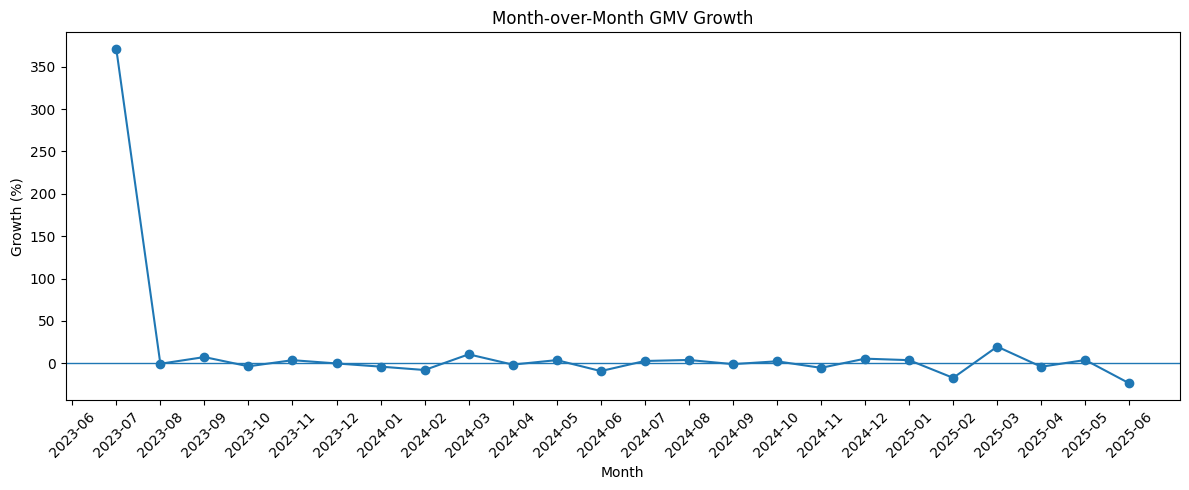

In [21]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_gmv["Month"].astype(str),
    monthly_gmv["MoM_Growth_%"],
    marker="o"
)

plt.axhline(0, linewidth=1)

plt.title("Month-over-Month GMV Growth")
plt.xlabel("Month")
plt.ylabel("Growth (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**8. Top Category Revenue Share**

In [22]:
category_data = order_items_df.merge(
    products_df[["product_id", "category"]],
    on="product_id",
    how="left"
)

In [23]:
category_data.head()

,item_id,order_id,product_id,product_name,category_x,quantity,unit_price,gst_rate,gst_amount,discount_amount,total_price,category_y
0,ITM0000001,ORD000001,PRD0522,HCL Cricket Bat Ultra,Sports & Fitness,1,40989,12,4918.68,7861.45,38046.23,Sports & Fitness
1,ITM0000002,ORD000001,PRD0094,Berger Router Pro,Electronics,1,62532,18,11255.76,12373.11,61414.65,Electronics
2,ITM0000003,ORD000001,PRD0613,Voltas Educational Toy Standard,Toys & Baby,1,1585,12,190.20,251.89,1523.31,Toys & Baby
3,ITM0000004,ORD000002,PRD0556,Ambrane Cycle Standard,Sports & Fitness,3,1107,12,398.52,631.44,3088.08,Sports & Fitness
4,ITM0000005,ORD000002,PRD0026,Pebble Tablet Premium,Electronics,2,114448,18,41201.28,18707.35,251389.93,Electronics


In [24]:
category_data = category_data.merge(
    orders_df[
        ["order_id", "status"]
    ],
    on="order_id",
    how="left"
)

In [25]:
category_data["revenue"] = (
    category_data["quantity"] * category_data["unit_price"]
)

In [26]:
delivered_category_data = category_data[
    category_data["status"] == "Delivered"
]

In [27]:
category_revenue = (
    delivered_category_data
    .groupby("category_y")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

,revenue
category_y,
Electronics,996406456
Sports & Fitness,313462362
Home & Kitchen,154490755
Fashion,101956130
Automotive,68268211
Office Supplies,56238358
Toys & Baby,29268303
Beauty & Health,20093621
Grocery,13398377


In [28]:
category_share = (
    category_revenue
    / category_revenue.sum()
    * 100
)

category_share = category_share.round(2)

category_share

,revenue
category_y,
Electronics,56.50
Sports & Fitness,17.77
Home & Kitchen,8.76
Fashion,5.78
Automotive,3.87
Office Supplies,3.19
Toys & Baby,1.66
Beauty & Health,1.14
Grocery,0.76


In [29]:
top_category = category_share.idxmax()
top_category_share = category_share.max()

print("Top Category:", top_category)
print("Revenue Share:", top_category_share, "%")

Top Category: Electronics
Revenue Share: 56.5 %


In [30]:
if top_category_share > 60:
    print("Warning: High concentration risk")
else:
    print("Category concentration is within the benchmark")

Category concentration is within the benchmark


**9. Payment Failure Rate**

In [31]:
payments_df.head()

,payment_id,order_id,customer_id,payment_date,payment_time,payment_method,amount,status,transaction_id,bank_name,gateway,refund_amount,refund_date
0,PAY000001,ORD000001,CUST02946,22-05-2025,17:10:00,Cash on Delivery,100984.19,Success,TXN5110698474,SBI,Google Pay,0,NaN
1,PAY000002,ORD000002,CUST04232,16-10-2023,05:32:00,UPI,254478.01,Success,TXN4067460377,IndusInd,Google Pay,0,NaN
2,PAY000003,ORD000003,CUST08078,08-10-2023,12:32:00,Debit Card,32557.06,Success,TXN7056710694,Axis Bank,PhonePe,0,NaN
3,PAY000004,ORD000004,CUST09612,02-10-2023,08:05:00,UPI,24836.94,Success,TXN7460208257,Axis Bank,PhonePe,0,NaN
4,PAY000005,ORD000005,CUST03065,15-06-2024,20:19:00,UPI,156689.29,Success,TXN5835043807,PNB,Razorpay,0,NaN


In [32]:
total_payments = len(payments_df)

failed_payments = len(
    payments_df[
        payments_df["status"] == "Failed"
    ]
)

payment_failure_rate = (
    failed_payments / total_payments
) * 100

print("Total Payments:", total_payments)
print("Failed Payments:", failed_payments)
print(
    "Payment Failure Rate:",
    round(payment_failure_rate, 2),
    "%"
)

Total Payments: 50000
Failed Payments: 1748
Payment Failure Rate: 3.5 %


In [33]:
if payment_failure_rate < 2:
    print("Target: < 2%")
    print("Status: Target Met")
else:
    print("Target: < 2%")
    print("Status: Target Missed")

Target: < 2%
Status: Target Missed


**10. Inventory Fill Rate**

In [34]:
total_skus = len(inventory_df)

in_stock_skus = len(
    inventory_df[
        inventory_df["quantity_available"] > 0
    ]
)

inventory_fill_rate = (
    in_stock_skus / total_skus
) * 100

print("Total SKUs:", total_skus)
print("In Stock SKUs:", in_stock_skus)
print(
    "Inventory Fill Rate:",
    round(inventory_fill_rate, 2),
    "%"
)

Total SKUs: 1000
In Stock SKUs: 998
Inventory Fill Rate: 99.8 %


In [35]:
if inventory_fill_rate > 95:
    print("Target: > 95%")
    print("Status: Target Met")
else:
    print("Target: > 95%")
    print("Status: Target Missed")

Target: > 95%
Status: Target Met


**cohort analysis**

In [39]:
customers_df[
    ["customer_id", "registration_date"]
].head()

,customer_id,registration_date
0,CUST00001,30-07-2024
1,CUST00002,05-07-2023
2,CUST00003,14-05-2022
3,CUST00004,21-01-2025
4,CUST00005,06-06-2023


In [40]:
orders_df[
    ["order_id", "customer_id", "order_date"]
].head()

,order_id,customer_id,order_date
0,ORD000001,CUST02946,2025-05-22
1,ORD000002,CUST04232,2023-10-16
2,ORD000003,CUST08078,2023-10-08
3,ORD000004,CUST09612,2023-10-02
4,ORD000005,CUST03065,2024-06-15


In [43]:
customers_df["registration_date"] = pd.to_datetime(
    customers_df["registration_date"],
    errors="coerce"
)

customers_df["cohort_month"] = (
    customers_df["registration_date"]
    .dt.to_period("M")
)

/tmp/ipykernel_2004/2434153153.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  customers_df["registration_date"] = pd.to_datetime(


In [44]:
customers_df[
    ["customer_id", "registration_date", "cohort_month"]
].head()

,customer_id,registration_date,cohort_month
0,CUST00001,2024-07-30,2024-07
1,CUST00002,2023-07-05,2023-07
2,CUST00003,2022-05-14,2022-05
3,CUST00004,2025-01-21,2025-01
4,CUST00005,2023-06-06,2023-06


In [45]:
cohort_data = orders_df.merge(
    customers_df[
        [
            "customer_id",
            "registration_date",
            "cohort_month"
        ]
    ],
    on="customer_id",
    how="inner"
)

In [46]:
cohort_data.head()

,order_id,customer_id,order_date,order_time,status,city,state,pincode,total_amount,gst_amount,...,final_amount,payment_method,shipping_partner,tracking_id,delivered_date,is_cod,channel,month,registration_date,cohort_month
0,ORD000001,CUST02946,2025-05-22,17:10:00,Processing,Pune,Maharashtra,300862,100984.19,16364.64,...,100984.19,Cash on Delivery,BlueDart,TRK354572763,NaN,1,App,2025-05,2021-01-10,2021-01
1,ORD000002,CUST04232,2023-10-16,05:32:00,Delivered,Ludhiana,Punjab,387852,254478.01,41599.80,...,254478.01,UPI,DTDC,TRK272838570,19-10-2023,0,Website,2023-10,2021-05-17,2021-05
2,ORD000003,CUST08078,2023-10-08,12:32:00,Cancelled,Meerut,Uttar Pradesh,294014,32557.06,3562.92,...,32557.06,Debit Card,Amazon Logistics,TRK338505401,NaN,0,App,2023-10,2020-10-28,2020-10
3,ORD000004,CUST09612,2023-10-02,08:05:00,Delivered,Nashik,Maharashtra,626047,24836.94,3092.88,...,24836.94,UPI,DTDC,TRK289792017,09-10-2023,0,Mobile Web,2023-10,2024-01-29,2024-01
4,ORD000005,CUST03065,2024-06-15,20:19:00,Delivered,Moradabad,Uttar Pradesh,409210,156689.29,25092.36,...,156689.29,UPI,Ecom Express,TRK978240041,22-06-2024,0,App,2024-06,2024-09-04,2024-09


In [63]:
cohort_data["order_month"] = (
    cohort_data["order_date"]
    .dt.to_period("M")
)

In [61]:
cohort_data[
    [
        "customer_id",
        "cohort_month",
        "order_month"
    ]
].head()

,customer_id,cohort_month,order_month
0,CUST02946,2021-01,2025-05
1,CUST04232,2021-05,2023-10
2,CUST08078,2020-10,2023-10
3,CUST09612,2024-01,2023-10
4,CUST03065,2024-09,2024-06


In [62]:
cohort_data["cohort_index"] = (
    (cohort_data["order_month"].dt.year
     - cohort_data["cohort_month"].dt.year) * 12
    +
    (cohort_data["order_month"].dt.month
     - cohort_data["cohort_month"].dt.month)
    + 1
)

In [64]:
cohort_data[
    [
        "customer_id",
        "cohort_month",
        "order_month",
        "cohort_index"
    ]
].head(20)

,customer_id,cohort_month,order_month,cohort_index
0,CUST02946,2021-01,2025-05,53
1,CUST04232,2021-05,2023-10,30
2,CUST08078,2020-10,2023-10,37
3,CUST09612,2024-01,2023-10,-2
4,CUST03065,2024-09,2024-06,-2
5,CUST00643,2022-12,2025-03,28
6,CUST00754,2023-11,2025-04,18
7,CUST02760,2024-09,2024-08,0
8,CUST01691,2024-12,2024-02,-9
9,CUST03540,2024-02,2024-08,7


In [65]:
cohort_orders = (
    cohort_data
    .groupby(
        ["cohort_month", "cohort_index"]
    )["order_id"]
    .count()
    .reset_index()
)

In [53]:
cohort_orders

,cohort_month,cohort_index,order_id
0,2020-06,37,2
1,2020-06,38,5
2,2020-06,39,8
3,2020-06,40,3
4,2020-06,41,7
...,...,...,...
1520,2025-06,-3,18
1521,2025-06,-2,25
1522,2025-06,-1,42
1523,2025-06,0,36


In [66]:
negative_cohort = cohort_data[
    cohort_data["cohort_index"] < 1
]

negative_cohort[
    [
        "customer_id",
        "cohort_month",
        "order_month",
        "cohort_index"
    ]
].head(20)

,customer_id,cohort_month,order_month,cohort_index
3,CUST09612,2024-01,2023-10,-2
4,CUST03065,2024-09,2024-06,-2
7,CUST02760,2024-09,2024-08,0
8,CUST01691,2024-12,2024-02,-9
12,CUST07476,2025-01,2024-12,0
21,CUST06171,2024-10,2024-04,-5
24,CUST06880,2025-01,2024-05,-7
25,CUST08711,2025-06,2024-06,-11
27,CUST06835,2024-04,2023-06,-9
35,CUST06204,2024-10,2024-01,-8


In [67]:
print("Negative cohort records:",
      len(negative_cohort))

Negative cohort records: 9875


In [54]:
cohort_pivot = cohort_orders.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="order_id"
)

In [69]:
negative_cohort[
    [
        "customer_id",

        "order_date",
        "cohort_month",
        "order_month",
        "cohort_index"
    ]
].head(20)

,customer_id,order_date,cohort_month,order_month,cohort_index
3,CUST09612,2023-10-02,2024-01,2023-10,-2
4,CUST03065,2024-06-15,2024-09,2024-06,-2
7,CUST02760,2024-08-12,2024-09,2024-08,0
8,CUST01691,2024-02-06,2024-12,2024-02,-9
12,CUST07476,2024-12-16,2025-01,2024-12,0
21,CUST06171,2024-04-03,2024-10,2024-04,-5
24,CUST06880,2024-05-23,2025-01,2024-05,-7
25,CUST08711,2024-06-29,2025-06,2024-06,-11
27,CUST06835,2023-06-26,2024-04,2023-06,-9
35,CUST06204,2024-01-14,2024-10,2024-01,-8


In [70]:
cohort_data_clean = cohort_data[
    cohort_data["cohort_index"] >= 1
].copy()

In [71]:
cohort_data_clean["cohort_index"].min()

1

In [72]:
cohort_orders = (
    cohort_data_clean
    .groupby(
        ["cohort_month", "cohort_index"]
    )["order_id"]
    .count()
    .reset_index()
)

In [73]:
cohort_pivot = cohort_orders.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="order_id"
).fillna(0)

In [74]:
cohort_pivot.columns = [
    f"Month {int(col)}"
    for col in cohort_pivot.columns
]

In [75]:
cohort_pivot

,Month 1,Month 2,Month 3,Month 4,Month 5,Month 6,Month 7,Month 8,Month 9,Month 10,...,Month 52,Month 53,Month 54,Month 55,Month 56,Month 57,Month 58,Month 59,Month 60,Month 61
cohort_month,,,,,,,,,,,,,,,,,,,,,
2020-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.0,9.0,10.0,4.0,9.0,10.0,7.0,8.0,3.0,2.0
2020-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,37.0,48.0,49.0,30.0,32.0,49.0,39.0,43.0,35.0,0.0
2020-08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,41.0,53.0,42.0,33.0,47.0,35.0,38.0,19.0,0.0,0.0
2020-09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,29.0,24.0,18.0,22.0,19.0,35.0,23.0,0.0,0.0,0.0
2020-10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,42.0,24.0,40.0,40.0,55.0,34.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-02,23.0,29.0,33.0,34.0,34.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-03,40.0,42.0,35.0,23.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-04,40.0,30.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [76]:
cohort_data_clean = cohort_data[
    cohort_data["cohort_index"] >= 1
].copy()

In [77]:
cohort_data["cohort_index"] = (
    (cohort_data["order_month"].dt.year
     - cohort_data["cohort_month"].dt.year) * 12
    +
    (cohort_data["order_month"].dt.month
     - cohort_data["cohort_month"].dt.month)
    + 1
)

In [78]:
cohort_data["cohort_index"].value_counts().sort_index()

,count
cohort_index,
-23,7
-22,42
-21,82
-20,110
-19,134
...,...
57,163
58,107
59,70


**KPI Report**

In [36]:
kpi_report = pd.DataFrame({
    "KPI": [
        "Gross Merchandise Value (GMV)",
        "Net Revenue",
        "Average Order Value (AOV)",
        "Cancellation Rate",
        "Return Rate",
        "Premium / Regular CLV Ratio",
        "Payment Failure Rate",
        "Inventory Fill Rate"
    ],

    "Actual": [
        gmv,
        net_revenue,
        aov,
        cancellation_rate,
        return_rate,
        premium_regular_ratio,
        payment_failure_rate,
        inventory_fill_rate
    ],

    "Target": [
        "Business Size",
        "Delivered Revenue",
        "Higher is Better",
        "< 10%",
        "< 8%",
        "3x",
        "< 2%",
        "> 95%"
    ]
})

kpi_report

,KPI,Actual,Target
0,Gross Merchandise Value (GMV),3.147386e+09,Business Size
1,Net Revenue,2.053859e+09,Delivered Revenue
2,Average Order Value (AOV),6.319759e+04,Higher is Better
3,Cancellation Rate,1.199200e+01,< 10%
4,Return Rate,3.077018e+01,< 8%
5,Premium / Regular CLV Ratio,1.472169e+00,3x
6,Payment Failure Rate,3.496000e+00,< 2%
7,Inventory Fill Rate,9.980000e+01,> 95%


In [37]:
kpi_report["Status"] = [
    "Calculated",
    "Calculated",
    "Calculated",

    "Target Met" if cancellation_rate < 10
    else "Target Missed",

    "Target Met" if return_rate < 8
    else "Target Missed",

    "Target Met" if premium_regular_ratio >= 3
    else "Target Missed",

    "Target Met" if payment_failure_rate < 2
    else "Target Missed",

    "Target Met" if inventory_fill_rate > 95
    else "Target Missed"
]

In [38]:
kpi_report.to_csv(
    "Phase_3_KPI_Report.csv",
    index=False
)

print("Phase 3 KPI report created successfully.")

Phase 3 KPI report created successfully.
